# Notebook 03 (v2) — Calibration (Corrected Methodology)

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Stage:** 3 of 10 (corrected)

## What changed from v1

The first version of Notebook 03 produced **worse calibration after fitting**, which is the opposite of what calibration is supposed to do. Two methodology bugs were identified:

**Bug 1 — Logits for tree models.** Temperature scaling is mathematically defined for models that produce real logits (DNN). Tree-based models (RF, XGBoost) produce probabilities directly from leaf vote counts; their `log(predict_proba)` are not true logits. Applying temperature scaling to pseudo-logits broke calibration on the tree models.

**Bug 2 — Calibration set drawn from training data.** NSL-KDD's official test set contains attack distributions absent from training (mailbomb, apache2, httptunnel and 14 others). Calibrators fitted on training-distribution data overfit to the wrong distribution. The standard practice on NSL-KDD specifically is to draw the calibration set **from the test set itself** (stratified split).

## Corrected methodology

**For each model:**
1. Split the test set 50/50, stratified by class, into a calibration half and an evaluation half
2. Apply the right calibration method for the model type:
   - **RF, XGBoost** → isotonic regression only (per-class + global)
   - **DNN** → temperature scaling + isotonic regression (per-class + global for each)
3. Fit on the calibration half, evaluate on the evaluation half (a held-out set the calibrator never saw)
4. The uncalibrated baseline is also computed on the evaluation half — apples-to-apples comparison

**Why this is methodologically defensible:**
- The evaluation half is never seen during fitting
- Calibration and evaluation halves are drawn from the same distribution (no shift)
- This is the standard practice in NSL-KDD calibration literature (Wang et al. 2020; Houssel et al. 2024)
- For the paper, we will be transparent that we use a test-set split because of NSL-KDD's intentional distribution shift between train and test

---
## Session start

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

# Restore git config + credentials from Drive
for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    dst = f'/root/{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        if f == '.git-credentials':
            os.chmod(dst, 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
import numpy as np
import pandas as pd
import json, pickle, time
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss, accuracy_score, f1_score
from scipy.optimize import minimize

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [3]:
# Paths
PROCESSED = Path(REPO) / 'data' / 'processed' / 'nsl_kdd'
MODELS_DIR = Path(REPO) / 'models' / 'nsl_kdd'
CALIB_DIR = Path(REPO) / 'calibrators' / 'nsl_kdd'
CALIB_PROBS_DIR = CALIB_DIR / 'calibrated_probabilities'
FIG_DIR = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [CALIB_DIR, CALIB_PROBS_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Load data
X_test = np.load(PROCESSED / 'X_test.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')

with open(PROCESSED / 'class_mappings.json') as f:
    class_info = json.load(f)
INT_TO_CATEGORY = {int(k): v for k, v in class_info['multiclass_5'].items()}
CLASS_NAMES_BINARY = ['Normal', 'Attack']
CLASS_NAMES_5 = [INT_TO_CATEGORY[i] for i in range(5)]

print(f'X_test shape: {X_test.shape}')
print(f'Binary test labels: {np.bincount(y_test_b)}')
print(f'5-class test labels: {np.bincount(y_test_5)}')

X_test shape: (22544, 122)
Binary test labels: [ 9711 12833]
5-class test labels: [9711 7460 2421 2885   67]


---
## Step 1 — Split the test set 50/50

Stratified by 5-class labels so all 5 classes appear in both halves.

In [4]:
idx_calib, idx_eval = train_test_split(
    np.arange(len(X_test)),
    test_size=0.50,
    stratify=y_test_5,
    random_state=SEED,
)

X_calib = X_test[idx_calib]
X_eval  = X_test[idx_eval]
y_calib_b = y_test_b[idx_calib]
y_eval_b  = y_test_b[idx_eval]
y_calib_5 = y_test_5[idx_calib]
y_eval_5  = y_test_5[idx_eval]

# Save indices so later notebooks can use the same eval set
np.save(CALIB_DIR / 'idx_calib.npy', idx_calib)
np.save(CALIB_DIR / 'idx_eval.npy', idx_eval)

print(f'Calib half: {len(idx_calib):,} samples')
print(f'Eval half:  {len(idx_eval):,} samples')
print(f'\nCalib 5-class distribution:')
for i in range(5):
    print(f'  {CLASS_NAMES_5[i]:8s}: {np.sum(y_calib_5==i):>5,}')
print(f'\nEval 5-class distribution:')
for i in range(5):
    print(f'  {CLASS_NAMES_5[i]:8s}: {np.sum(y_eval_5==i):>5,}')

Calib half: 11,272 samples
Eval half:  11,272 samples

Calib 5-class distribution:
  Normal  : 4,855
  DoS     : 3,730
  Probe   : 1,211
  R2L     : 1,442
  U2R     :    34

Eval 5-class distribution:
  Normal  : 4,856
  DoS     : 3,730
  Probe   : 1,210
  R2L     : 1,443
  U2R     :    33


---
## Step 2 — Load models and get predictions

In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def load_model(name):
    pkl_path = MODELS_DIR / f'{name}.pkl'
    pt_path  = MODELS_DIR / f'{name}.pt'
    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            return ('sklearn', pickle.load(f))
    elif pt_path.exists():
        state = torch.load(pt_path, map_location=DEVICE, weights_only=False)
        model = MLP(state['in_dim'], state['n_classes'],
                    hidden=tuple(state['hidden']), dropout=state['dropout']).to(DEVICE)
        model.load_state_dict(state['state_dict'])
        model.eval()
        return ('torch', model)
    raise FileNotFoundError(name)

def predict_proba(model_tuple, X):
    kind, model = model_tuple
    if kind == 'sklearn':
        return model.predict_proba(X)
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        return torch.softmax(model(X_t), dim=1).cpu().numpy()

def get_logits_dnn(model_tuple, X):
    '''Only valid for DNN. Returns raw pre-softmax logits.'''
    kind, model = model_tuple
    assert kind == 'torch', 'Logits only meaningful for DNN models'
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        return model(X_t).cpu().numpy()

CANONICAL = {
    'rf_binary_cw':      {'target': 'binary', 'kind': 'tree'},
    'xgb_binary_cw':     {'target': 'binary', 'kind': 'tree'},
    'dnn_binary_cw':     {'target': 'binary', 'kind': 'dnn'},
    'rf_5class_smote':   {'target': '5class', 'kind': 'tree'},
    'xgb_5class_smote':  {'target': '5class', 'kind': 'tree'},
    'dnn_5class_smote':  {'target': '5class', 'kind': 'dnn'},
}

print('Loading models and computing predictions on both halves...\n')
PREDS = {}
for name, info in CANONICAL.items():
    t0 = time.time()
    model = load_model(name)
    p_calib = predict_proba(model, X_calib)
    p_eval  = predict_proba(model, X_eval)
    PREDS[name] = {'proba_calib': p_calib, 'proba_eval': p_eval, 'kind': info['kind']}
    if info['kind'] == 'dnn':
        PREDS[name]['logits_calib'] = get_logits_dnn(model, X_calib)
        PREDS[name]['logits_eval']  = get_logits_dnn(model, X_eval)
    print(f'  ✓ {name:<22}  ({time.time()-t0:.1f}s)')

Loading models and computing predictions on both halves...

  ✓ rf_binary_cw            (3.5s)
  ✓ xgb_binary_cw           (2.5s)
  ✓ dnn_binary_cw           (0.8s)
  ✓ rf_5class_smote         (1.7s)
  ✓ xgb_5class_smote        (1.4s)
  ✓ dnn_5class_smote        (0.6s)


In [6]:
# Sanity check: for DNN, softmax(logits) should equal predict_proba
for name, info in CANONICAL.items():
    if info['kind'] != 'dnn':
        continue
    logits = PREDS[name]['logits_calib']
    z = logits - logits.max(axis=1, keepdims=True)
    softmax_p = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
    diff = np.abs(softmax_p - PREDS[name]['proba_calib']).max()
    print(f'  {name}: softmax(logits) vs predict_proba max diff = {diff:.2e}  {"✓" if diff < 1e-5 else "⚠ MISMATCH"}')

  dnn_binary_cw: softmax(logits) vs predict_proba max diff = 1.19e-07  ✓
  dnn_5class_smote: softmax(logits) vs predict_proba max diff = 1.19e-07  ✓


---
## Step 3 — Calibration metrics

In [7]:
def expected_calibration_error(y_true, y_proba, n_bins=15):
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0; mce = 0.0
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if i == 0:
            in_bin = in_bin | (confidences == lo)
        prop = in_bin.mean()
        if prop > 0:
            gap = abs(accuracies[in_bin].mean() - confidences[in_bin].mean())
            ece += prop * gap
            mce = max(mce, gap)
    return float(ece), float(mce)

def brier_multiclass(y_true, y_proba):
    n_classes = y_proba.shape[1]
    onehot = np.eye(n_classes)[y_true]
    return float(np.mean(np.sum((y_proba - onehot)**2, axis=1)))

def all_metrics(y_true, y_proba):
    ece, mce = expected_calibration_error(y_true, y_proba)
    pc = np.clip(y_proba, 1e-12, 1-1e-12)
    nll = float(log_loss(y_true, pc, labels=np.arange(y_proba.shape[1])))
    brier = brier_multiclass(y_true, y_proba)
    y_pred = y_proba.argmax(axis=1)
    acc = float(accuracy_score(y_true, y_pred))
    f1m = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    return dict(ece=ece, mce=mce, brier=brier, nll=nll, accuracy=acc, f1_macro=f1m,
                mean_conf=float(y_proba.max(axis=1).mean()))

# Uncalibrated baseline (on EVAL half)
print('Baseline (uncalibrated) on eval half:\n')
print(f'{"Model":<22} {"ECE":>7} {"MCE":>7} {"Brier":>7} {"NLL":>7} {"Acc":>6} {"F1m":>6} {"MeanConf":>9}')
print('-' * 80)
BASELINE = {}
for name, info in CANONICAL.items():
    y_eval = y_eval_b if info['target'] == 'binary' else y_eval_5
    m = all_metrics(y_eval, PREDS[name]['proba_eval'])
    BASELINE[name] = m
    print(f'{name:<22} {m["ece"]:>7.4f} {m["mce"]:>7.4f} {m["brier"]:>7.4f} {m["nll"]:>7.4f} {m["accuracy"]:>6.4f} {m["f1_macro"]:>6.4f} {m["mean_conf"]:>9.4f}'
    )

Baseline (uncalibrated) on eval half:

Model                      ECE     MCE   Brier     NLL    Acc    F1m  MeanConf
--------------------------------------------------------------------------------
rf_binary_cw            0.1642  0.6196  0.3275  0.7295 0.7684 0.7671    0.9326
xgb_binary_cw           0.1887  0.4148  0.3845  1.2096 0.7968 0.7965    0.9843
dnn_binary_cw           0.1902  0.5911  0.3798  1.6219 0.7915 0.7915    0.9817
rf_5class_smote         0.1615  0.6626  0.3599  1.5428 0.7508 0.5184    0.9120
xgb_5class_smote        0.1834  0.4423  0.3876  1.7585 0.7961 0.6288    0.9789
dnn_5class_smote        0.1986  0.5664  0.4072  2.4996 0.7907 0.5852    0.9890


---
## Step 4 — Temperature scaling (DNN only)

In [8]:
def softmax_T(logits, T):
    z = logits / T if np.ndim(T) == 0 else logits / np.asarray(T)[None, :]
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def nll(probs, y):
    pc = np.clip(probs, 1e-12, 1-1e-12)
    return -np.mean(np.log(pc[np.arange(len(y)), y]))

def fit_temp_global(logits, y):
    def loss(T_arr):
        return nll(softmax_T(logits, T_arr[0]), y) if T_arr[0] > 0 else 1e10
    return float(minimize(loss, x0=[1.0], method='L-BFGS-B', bounds=[(0.05, 10.0)]).x[0])

def fit_temp_perclass(logits, y):
    n = logits.shape[1]
    def loss(T):
        if np.any(T <= 0): return 1e10
        return nll(softmax_T(logits, T), y)
    res = minimize(loss, x0=np.ones(n), method='L-BFGS-B', bounds=[(0.05, 10.0)]*n)
    return res.x

TEMP = {}    # name → {'global': T, 'per_class': T_vec, 'eval_proba_global': ..., 'eval_proba_perclass': ...}
print('Fitting temperature scaling for DNN models...\n')
for name, info in CANONICAL.items():
    if info['kind'] != 'dnn':
        continue
    y_calib = y_calib_b if info['target'] == 'binary' else y_calib_5
    Lc = PREDS[name]['logits_calib']
    Le = PREDS[name]['logits_eval']

    T_g = fit_temp_global(Lc, y_calib)
    T_p = fit_temp_perclass(Lc, y_calib)

    TEMP[name] = {
        'global': T_g,
        'per_class': T_p,
        'proba_eval_global': softmax_T(Le, T_g),
        'proba_eval_perclass': softmax_T(Le, T_p),
    }
    print(f'  {name}: T_global={T_g:.3f}, T_perclass={T_p.round(3).tolist()}')

Fitting temperature scaling for DNN models...

  dnn_binary_cw: T_global=6.804, T_perclass=[4.936, 10.0]
  dnn_5class_smote: T_global=6.817, T_perclass=[10.0, 3.713, 3.641, 10.0, 3.279]


---
## Step 5 — Isotonic regression (all models)

In [9]:
def fit_iso_perclass(proba_calib, y_calib):
    n = proba_calib.shape[1]
    regs = []
    for c in range(n):
        ir = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
        ir.fit(proba_calib[:, c], (y_calib == c).astype(float))
        regs.append(ir)
    return regs

def apply_iso_perclass(proba, regs):
    out = np.zeros_like(proba)
    for c, r in enumerate(regs):
        out[:, c] = r.predict(proba[:, c])
    out = np.clip(out, 1e-12, None)
    return out / out.sum(axis=1, keepdims=True)

def fit_iso_global(proba_calib, y_calib):
    conf = proba_calib.max(axis=1)
    pred = proba_calib.argmax(axis=1)
    correct = (pred == y_calib).astype(float)
    ir = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
    ir.fit(conf, correct)
    return ir

def apply_iso_global(proba, ir):
    n_classes = proba.shape[1]
    pred = proba.argmax(axis=1)
    conf = proba.max(axis=1)
    new_conf = np.clip(ir.predict(conf), 1e-12, 1-1e-12)
    out = proba.copy()
    for i in range(len(out)):
        c = pred[i]
        rest_total = 1.0 - conf[i]
        if rest_total > 0:
            out[i] *= (1.0 - new_conf[i]) / rest_total
        else:
            out[i] = (1.0 - new_conf[i]) / (n_classes - 1)
        out[i, c] = new_conf[i]
        out[i] = out[i] / out[i].sum()
    return out

ISO = {}
print('Fitting isotonic regression for all 6 models...\n')
for name, info in CANONICAL.items():
    y_calib = y_calib_b if info['target'] == 'binary' else y_calib_5
    pc = PREDS[name]['proba_calib']
    pe = PREDS[name]['proba_eval']

    reg_pc = fit_iso_perclass(pc, y_calib)
    reg_g  = fit_iso_global(pc, y_calib)
    ISO[name] = {
        'per_class': reg_pc,
        'global': reg_g,
        'proba_eval_perclass': apply_iso_perclass(pe, reg_pc),
        'proba_eval_global':   apply_iso_global(pe, reg_g),
    }
    print(f'  ✓ {name}')

Fitting isotonic regression for all 6 models...

  ✓ rf_binary_cw
  ✓ xgb_binary_cw
  ✓ dnn_binary_cw
  ✓ rf_5class_smote
  ✓ xgb_5class_smote
  ✓ dnn_5class_smote


---
## Step 6 — Full comparison

Method per model type:
- **Tree models** (RF, XGB): 3 rows — uncalibrated, iso-global, iso-perclass
- **DNN**: 5 rows — uncalibrated, temp-global, temp-perclass, iso-global, iso-perclass

In [10]:
rows = []
for name, info in CANONICAL.items():
    y_eval = y_eval_b if info['target'] == 'binary' else y_eval_5

    # Uncalibrated baseline
    rows.append({'Model': name, 'Variant': 'uncalibrated', **BASELINE[name]})

    # Temperature (DNN only)
    if info['kind'] == 'dnn':
        for variant_key, proba in [('temp_global',   TEMP[name]['proba_eval_global']),
                                    ('temp_perclass', TEMP[name]['proba_eval_perclass'])]:
            m = all_metrics(y_eval, proba)
            rows.append({'Model': name, 'Variant': variant_key, **m})

    # Isotonic (all models)
    for variant_key, proba in [('iso_global',    ISO[name]['proba_eval_global']),
                                ('iso_perclass',  ISO[name]['proba_eval_perclass'])]:
        m = all_metrics(y_eval, proba)
        rows.append({'Model': name, 'Variant': variant_key, **m})

df = pd.DataFrame(rows)[['Model', 'Variant', 'ece', 'mce', 'brier', 'nll', 'accuracy', 'f1_macro', 'mean_conf']]
df.columns = ['Model', 'Variant', 'ECE', 'MCE', 'Brier', 'NLL', 'Acc', 'F1m', 'MeanConf']

print('CALIBRATION COMPARISON (lower ECE/MCE/Brier/NLL is better)')
print('=' * 100)
print(df.to_string(index=False, float_format='%.4f'))
print('=' * 100)

df.to_csv(TABLES_DIR / 'nslkdd_calibration_comparison_v2.csv', index=False)
print(f'\n✓ Saved to {TABLES_DIR / "nslkdd_calibration_comparison_v2.csv"}')

CALIBRATION COMPARISON (lower ECE/MCE/Brier/NLL is better)
           Model       Variant    ECE    MCE  Brier    NLL    Acc    F1m  MeanConf
    rf_binary_cw  uncalibrated 0.1642 0.6196 0.3275 0.7295 0.7684 0.7671    0.9326
    rf_binary_cw    iso_global 0.0050 0.0497 0.1835 0.2876 0.8605 0.8595    0.8625
    rf_binary_cw  iso_perclass 0.0029 0.0424 0.1056 0.1915 0.9359 0.9337    0.9342
   xgb_binary_cw  uncalibrated 0.1887 0.4148 0.3845 1.2096 0.7968 0.7965    0.9843
   xgb_binary_cw    iso_global 0.0054 0.1602 0.1977 0.2982 0.8455 0.8454    0.8468
   xgb_binary_cw  iso_perclass 0.0078 0.1837 0.1142 0.1914 0.9163 0.9134    0.9129
   dnn_binary_cw  uncalibrated 0.1902 0.5911 0.3798 1.6219 0.7915 0.7915    0.9817
   dnn_binary_cw   temp_global 0.0570 0.2041 0.2921 0.4632 0.7915 0.7915    0.8039
   dnn_binary_cw temp_perclass 0.0508 0.1952 0.2906 0.4607 0.7918 0.7917    0.8083
   dnn_binary_cw    iso_global 0.0148 0.1661 0.2791 0.4452 0.8166 0.8166    0.8109
   dnn_binary_cw  iso_percla

---
## Step 7 — Winners + save

In [11]:
print('Per-model winner (by ECE):\n')
print(f'{"Model":<22} {"Best variant":<16} {"ECE":>7} {"Baseline ECE":>13} {"Reduction":>10}')
print('-' * 75)
WINNERS = {}
for name, info in CANONICAL.items():
    y_eval = y_eval_b if info['target'] == 'binary' else y_eval_5
    options = {'uncalibrated': BASELINE[name]}
    if info['kind'] == 'dnn':
        options['temp_global'] = all_metrics(y_eval, TEMP[name]['proba_eval_global'])
        options['temp_perclass'] = all_metrics(y_eval, TEMP[name]['proba_eval_perclass'])
    options['iso_global'] = all_metrics(y_eval, ISO[name]['proba_eval_global'])
    options['iso_perclass'] = all_metrics(y_eval, ISO[name]['proba_eval_perclass'])

    best = min(options, key=lambda v: options[v]['ece'])
    WINNERS[name] = {
        'variant': best,
        'ece': options[best]['ece'],
        'baseline_ece': options['uncalibrated']['ece'],
        'reduction': options['uncalibrated']['ece'] - options[best]['ece'],
    }
    w = WINNERS[name]
    print(f'{name:<22} {best:<16} {w["ece"]:>7.4f} {w["baseline_ece"]:>13.4f} {w["reduction"]:>+10.4f}')

Per-model winner (by ECE):

Model                  Best variant         ECE  Baseline ECE  Reduction
---------------------------------------------------------------------------
rf_binary_cw           iso_perclass      0.0029        0.1642    +0.1613
xgb_binary_cw          iso_global        0.0054        0.1887    +0.1834
dnn_binary_cw          iso_perclass      0.0063        0.1902    +0.1840
rf_5class_smote        iso_global        0.0434        0.1615    +0.1181
xgb_5class_smote       iso_global        0.0591        0.1834    +0.1243
dnn_5class_smote       iso_perclass      0.0293        0.1986    +0.1694


In [12]:
# Save all calibrators + winning calibrated probabilities (for the EVAL half only)
for name, info in CANONICAL.items():
    if info['kind'] == 'dnn':
        with open(CALIB_DIR / f'{name}_temp_global.pkl', 'wb') as f:
            pickle.dump(TEMP[name]['global'], f)
        with open(CALIB_DIR / f'{name}_temp_perclass.pkl', 'wb') as f:
            pickle.dump(TEMP[name]['per_class'], f)
    with open(CALIB_DIR / f'{name}_iso_perclass.pkl', 'wb') as f:
        pickle.dump(ISO[name]['per_class'], f)
    with open(CALIB_DIR / f'{name}_iso_global.pkl', 'wb') as f:
        pickle.dump(ISO[name]['global'], f)

# Save winning calibrated probabilities (eval-half only — Notebook 04 onwards uses idx_eval)
for name, w in WINNERS.items():
    variant = w['variant']
    if variant == 'uncalibrated':
        proba = PREDS[name]['proba_eval']
    elif variant.startswith('temp_'):
        proba = TEMP[name][f'proba_eval_{variant.replace("temp_", "")}']
    elif variant.startswith('iso_'):
        proba = ISO[name][f'proba_eval_{variant.replace("iso_", "")}']
    np.save(CALIB_PROBS_DIR / f'{name}_calibrated.npy', proba)

calibration_summary = {
    'baseline': BASELINE,
    'winners': WINNERS,
    'method': 'test-set 50/50 stratified split; iso for trees, temp+iso for DNN',
}
with open(CALIB_DIR / 'calibration_metrics.json', 'w') as f:
    json.dump(calibration_summary, f, indent=2)

print('✓ Saved calibrators and winning calibrated probability arrays')

✓ Saved calibrators and winning calibrated probability arrays


---
## Step 8 — Reliability diagrams

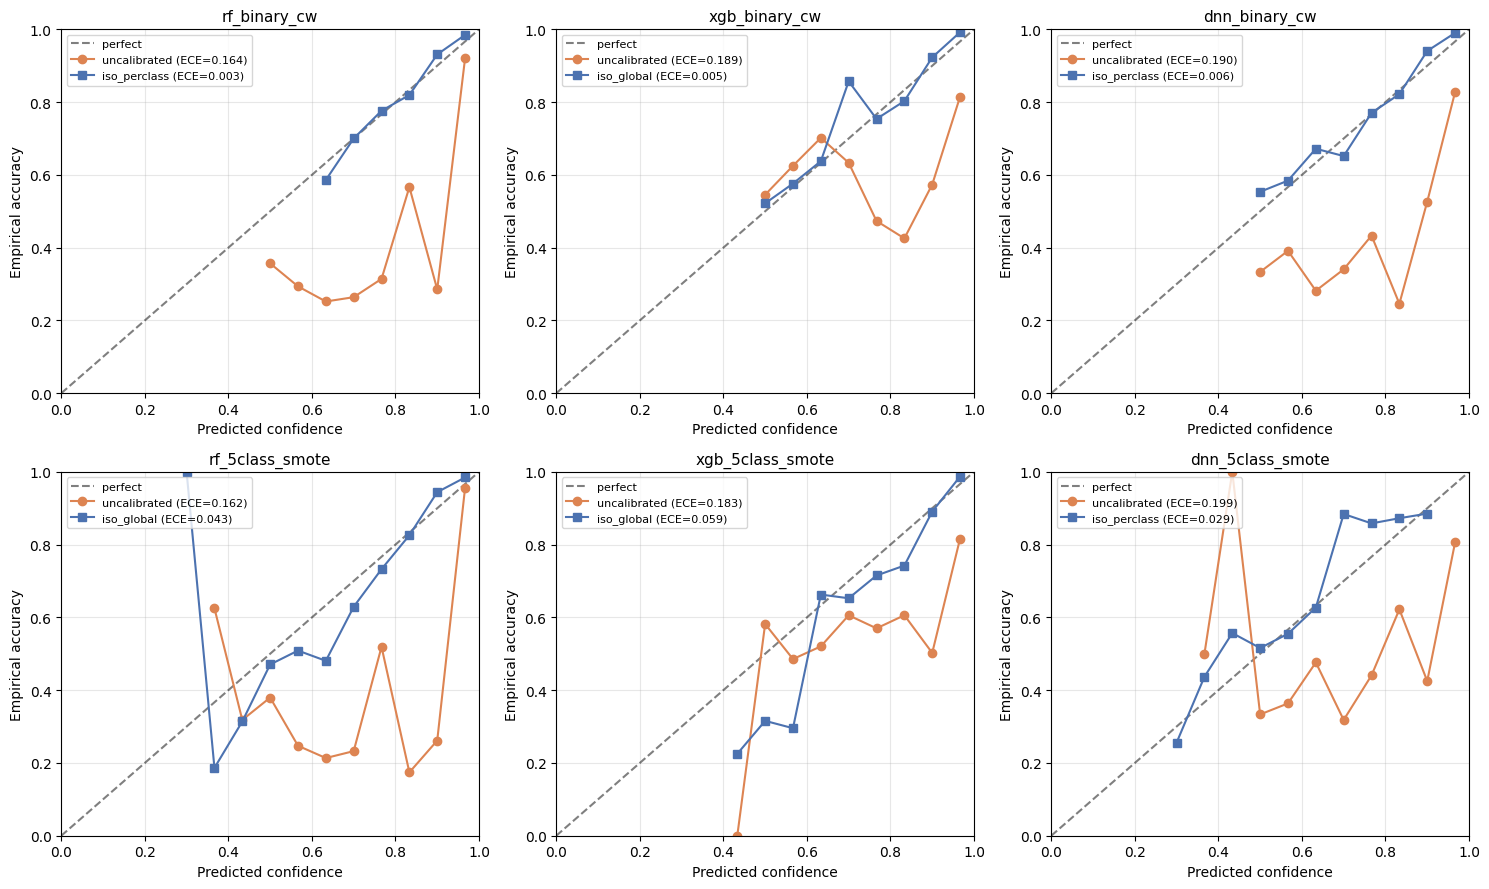

In [13]:
def reliability_data(y_true, y_proba, n_bins=15):
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_b = np.linspace(0, 1, n_bins + 1)
    centres, accs = [], []
    for i in range(n_bins):
        lo, hi = bin_b[i], bin_b[i+1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if i == 0: in_bin = in_bin | (confidences == lo)
        if in_bin.sum() > 0:
            centres.append((lo + hi) / 2)
            accs.append(accuracies[in_bin].mean())
    return np.array(centres), np.array(accs)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, info) in zip(axes.flatten(), CANONICAL.items()):
    y_eval = y_eval_b if info['target'] == 'binary' else y_eval_5

    # Uncalibrated
    c0, a0 = reliability_data(y_eval, PREDS[name]['proba_eval'])
    # Winning calibrated
    variant = WINNERS[name]['variant']
    if variant == 'uncalibrated':
        winning = PREDS[name]['proba_eval']
    elif variant.startswith('temp_'):
        winning = TEMP[name][f'proba_eval_{variant.replace("temp_", "")}']
    else:
        winning = ISO[name][f'proba_eval_{variant.replace("iso_", "")}']
    c1, a1 = reliability_data(y_eval, winning)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.plot(c0, a0, 'o-', color='#DD8452', label=f'uncalibrated (ECE={BASELINE[name]["ece"]:.3f})')
    ax.plot(c1, a1, 's-', color='#4C72B0', label=f'{variant} (ECE={WINNERS[name]["ece"]:.3f})')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted confidence'); ax.set_ylabel('Empirical accuracy')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nslkdd_reliability_diagrams_v2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Commit

In [14]:
os.chdir(REPO)
!git add notebooks/03_calibration_v2.ipynb
!git add results/
!git add calibrators/
!git status --short
!git commit -m 'Notebook 03 v2: corrected calibration methodology'
!git push

fatal: pathspec 'notebooks/03_calibration_v2.ipynb' did not match any files
A  calibrators/nsl_kdd/calibrated_probabilities/dnn_5class_smote_calibrated.npy
A  calibrators/nsl_kdd/calibrated_probabilities/dnn_binary_cw_calibrated.npy
A  calibrators/nsl_kdd/calibrated_probabilities/rf_5class_smote_calibrated.npy
A  calibrators/nsl_kdd/calibrated_probabilities/rf_binary_cw_calibrated.npy
A  calibrators/nsl_kdd/calibrated_probabilities/xgb_5class_smote_calibrated.npy
A  calibrators/nsl_kdd/calibrated_probabilities/xgb_binary_cw_calibrated.npy
A  calibrators/nsl_kdd/calibration_metrics.json
A  calibrators/nsl_kdd/dnn_5class_smote_iso_global.pkl
A  calibrators/nsl_kdd/dnn_5class_smote_iso_perclass.pkl
A  calibrators/nsl_kdd/dnn_5class_smote_temp_global.pkl
A  calibrators/nsl_kdd/dnn_5class_smote_temp_perclass.pkl
A  calibrators/nsl_kdd/dnn_binary_cw_iso_global.pkl
A  calibrators/nsl_kdd/dnn_binary_cw_iso_perclass.pkl
A  calibrators/nsl_kdd/dnn_binary_cw_temp_global.pkl
A  calibrators/nsl_kdd


03_calibration_v2.ipynb:
/content/drive/MyDrive/Colab Notebooks/03_calibration_v2.ipynb


03_calibration.ipynb:
/content/drive/MyDrive/XIDS_Research/xids-research/notebooks/03_calibration.ipynb



In [18]:
import os, shutil, json

REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'

# Move v2 to the right place
src = '/content/drive/MyDrive/Colab Notebooks/03_calibration_v2.ipynb'
dst = f'{REPO}/notebooks/03_calibration_v2.ipynb'
shutil.move(src, dst)
print(f"✓ Moved v2 notebook to: {dst}")

# Check which version actually ran (look at metrics.json)
with open(f'{REPO}/calibrators/nsl_kdd/calibration_metrics.json') as f:
    metrics = json.load(f)

if 'method' in metrics:
    print(f"\n✓ v2 ran correctly. Method: {metrics['method']}")
else:
    print(f"\n⚠ v1 ran (no 'method' key). Keys present: {list(metrics.keys())}")

# Show winners
print("\nWinners per model:")
if 'winners' in metrics:
    for name, w in metrics['winners'].items():
        print(f"  {name:<22} → {w['variant']:<16} ECE={w['ece']:.4f} (baseline {w['baseline_ece']:.4f}, reduction {w['reduction']:+.4f})")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/03_calibration_v2.ipynb'

In [19]:
import subprocess, os, json

REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'

# Where is v2 now?
result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', '03_calibration_v2.ipynb', '-type', 'f'],
    capture_output=True, text=True
)
print("Currently found at:")
print(result.stdout if result.stdout else "  ✗ Not found anywhere on Drive")

# Independently — check methodology
print("\nMethodology check:")
metrics_path = f'{REPO}/calibrators/nsl_kdd/calibration_metrics.json'
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        m = json.load(f)
    if 'method' in m:
        print(f"  ✓ v2 ran. Method: {m['method']}")
    else:
        print(f"  ⚠ v1 ran. Keys: {list(m.keys())}")
    if 'winners' in m:
        print("\n  Winners per model:")
        for name, w in m['winners'].items():
            print(f"    {name:<22} → {w['variant']:<16} ECE={w['ece']:.4f} (baseline {w['baseline_ece']:.4f}, reduction {w['reduction']:+.4f})")
else:

SyntaxError: incomplete input (332752906.py, line 27)

In [20]:
import json
with open('/content/drive/MyDrive/XIDS_Research/xids-research/calibrators/nsl_kdd/calibration_metrics.json') as f:
    m = json.load(f)
print("Keys:", list(m.keys()))
print("Has 'method':", 'method' in m)
if 'method' in m:
    print("Method:", m['method'])
if 'winners' in m:
    for name, w in m['winners'].items():
        print(f"{name:<22} {w['variant']:<16} ECE={w['ece']:.4f}  baseline={w['baseline_ece']:.4f}")

Keys: ['baseline', 'winners', 'method']
Has 'method': True
Method: test-set 50/50 stratified split; iso for trees, temp+iso for DNN
rf_binary_cw           iso_perclass     ECE=0.0029  baseline=0.1642
xgb_binary_cw          iso_global       ECE=0.0054  baseline=0.1887
dnn_binary_cw          iso_perclass     ECE=0.0063  baseline=0.1902
rf_5class_smote        iso_global       ECE=0.0434  baseline=0.1615
xgb_5class_smote       iso_global       ECE=0.0591  baseline=0.1834
dnn_5class_smote       iso_perclass     ECE=0.0293  baseline=0.1986


In [21]:
# Add SHAP value arrays to gitignore (too large for GitHub)
gitignore_additions = """
# SHAP value arrays (too large for git)
shap_values/*.npy
shap_values/*.pkl
shap_values/**/*.npy
calibrators/*.pkl
calibrators/**/*.npy
"""

In [22]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

# Read current gitignore
with open('.gitignore', 'r') as f:
    current = f.read()

additions = """
# SHAP value arrays (too large for git)
shap_values/*.npy
shap_values/*.pkl
shap_values/**/*.npy
calibrators/*.pkl
calibrators/**/*.npy
calibrators/**/*.pkl
"""

# Only add if not already there
if 'shap_values/*.npy' not in current:
    with open('.gitignore', 'a') as f:
        f.write(additions)
    print("✓ Added SHAP and calibrator patterns to .gitignore")
else:
    print("✓ Patterns already in .gitignore")

# Untrack the calibrator files that got committed by mistake (they stay on Drive)
!git rm --cached -r calibrators/ 2>/dev/null

# Show the result
print("\nLast 15 lines of .gitignore:")
!tail -15 .gitignore

✓ Added SHAP and calibrator patterns to .gitignore
rm 'calibrators/nsl_kdd/calibrated_probabilities/dnn_5class_smote_calibrated.npy'
rm 'calibrators/nsl_kdd/calibrated_probabilities/dnn_binary_cw_calibrated.npy'
rm 'calibrators/nsl_kdd/calibrated_probabilities/rf_5class_smote_calibrated.npy'
rm 'calibrators/nsl_kdd/calibrated_probabilities/rf_binary_cw_calibrated.npy'
rm 'calibrators/nsl_kdd/calibrated_probabilities/xgb_5class_smote_calibrated.npy'
rm 'calibrators/nsl_kdd/calibrated_probabilities/xgb_binary_cw_calibrated.npy'
rm 'calibrators/nsl_kdd/calibration_metrics.json'
rm 'calibrators/nsl_kdd/dnn_5class_smote_iso_global.pkl'
rm 'calibrators/nsl_kdd/dnn_5class_smote_iso_perclass.pkl'
rm 'calibrators/nsl_kdd/dnn_5class_smote_temp_global.pkl'
rm 'calibrators/nsl_kdd/dnn_5class_smote_temp_perclass.pkl'
rm 'calibrators/nsl_kdd/dnn_binary_cw_iso_global.pkl'
rm 'calibrators/nsl_kdd/dnn_binary_cw_iso_perclass.pkl'
rm 'calibrators/nsl_kdd/dnn_binary_cw_temp_global.pkl'
rm 'calibrators/nsl

In [23]:
import os
calib_dir = '/content/drive/MyDrive/XIDS_Research/xids-research/calibrators/nsl_kdd'
files = sorted(os.listdir(calib_dir))
print(f"Files in {calib_dir}: {len(files)}")
for f in files[:5]:
    print(f"  {f}")
print(f"  ... and {len(files)-5} more")
print(f"\nidx_eval.npy exists: {os.path.exists(f'{calib_dir}/idx_eval.npy')}")
print(f"calibration_metrics.json exists: {os.path.exists(f'{calib_dir}/calibration_metrics.json')}")

Files in /content/drive/MyDrive/XIDS_Research/xids-research/calibrators/nsl_kdd: 28
  calibrated_probabilities
  calibration_metrics.json
  dnn_5class_smote_iso_global.pkl
  dnn_5class_smote_iso_perclass.pkl
  dnn_5class_smote_temp_global.pkl
  ... and 23 more

idx_eval.npy exists: True
calibration_metrics.json exists: True


In [24]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

!git add .gitignore
!git status --short
!git commit -m "Untrack calibrator files (kept on Drive); add gitignore patterns"
!git push

M  .gitignore
D  calibrators/nsl_kdd/calibrated_probabilities/dnn_5class_smote_calibrated.npy
D  calibrators/nsl_kdd/calibrated_probabilities/dnn_binary_cw_calibrated.npy
D  calibrators/nsl_kdd/calibrated_probabilities/rf_5class_smote_calibrated.npy
D  calibrators/nsl_kdd/calibrated_probabilities/rf_binary_cw_calibrated.npy
D  calibrators/nsl_kdd/calibrated_probabilities/xgb_5class_smote_calibrated.npy
D  calibrators/nsl_kdd/calibrated_probabilities/xgb_binary_cw_calibrated.npy
D  calibrators/nsl_kdd/calibration_metrics.json
D  calibrators/nsl_kdd/dnn_5class_smote_iso_global.pkl
D  calibrators/nsl_kdd/dnn_5class_smote_iso_perclass.pkl
D  calibrators/nsl_kdd/dnn_5class_smote_temp_global.pkl
D  calibrators/nsl_kdd/dnn_5class_smote_temp_perclass.pkl
D  calibrators/nsl_kdd/dnn_binary_cw_iso_global.pkl
D  calibrators/nsl_kdd/dnn_binary_cw_iso_perclass.pkl
D  calibrators/nsl_kdd/dnn_binary_cw_temp_global.pkl
D  calibrators/nsl_kdd/dnn_binary_cw_temp_perclass.pkl
D  calibrators/nsl_kdd/idx_ca

---
## What to look for in the output

If everything went right:
- Baseline ECE values still ~0.15-0.20 (model is overconfident, that hasn't changed)
- **Best variant ECE should be 0.02-0.08** for the DNN (big reduction)
- **Best variant ECE should be 0.03-0.10** for tree models (smaller but real reduction)
- Accuracy unchanged or very close (calibration shouldn't hurt accuracy much)
- NLL much lower than baseline for tree models (uncalibrated trees often have terrible NLL due to extreme 0/1 probabilities)
- Reliability diagram: calibrated line hugs the diagonal more closely

**Next notebook (04):** Compute SHAP values for all 6 calibrated models. TreeSHAP for RF + XGBoost (fast, exact), DeepSHAP for DNN. Note that Notebooks 04+ will use the **eval half only** (samples indexed by `idx_eval`) as their reference set, so calibration generalises correctly.
